In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import os
from pathlib import Path
from sklearn.model_selection import train_test_split

In [3]:
# ── Same group-aware split as LuckBasedModel(2) — identical data, identical seed ──
# Only the model architecture changes. Everything else is held constant
# so the accuracy comparison is fair.

BASE = "/content/drive/MyDrive/KachornLuckbasedThSL/KachornThSL/data"

TARGET_SIGNS = [
    "คนหูหนวก", "คุณ", "ช่วย", "ขอบคุณ",
    "ฉัน", "ต้องการ", "เข้าใจ", "ไม่", "ถาม", "บอก", "finish", "none"
]

originals = []
for label_idx, sign in enumerate(TARGET_SIGNS):
    d = os.path.join(BASE, "processed", sign)
    if not os.path.exists(d):
        continue
    for f in os.listdir(d):
        if f.endswith(".npy"):
            originals.append((os.path.join(d, f), label_idx, sign, f[:-4]))

labels = [o[1] for o in originals]

train_orig, test_orig = train_test_split(
    originals, test_size=0.2, random_state=42, stratify=labels
)

X_test = np.array([np.load(o[0]) for o in test_orig])
y_test = np.array([o[1] for o in test_orig])

train_keys = {(o[2], o[3]) for o in train_orig}
X_train, y_train = [], []
for o in train_orig:
    X_train.append(np.load(o[0])); y_train.append(o[1])
for label_idx, sign in enumerate(TARGET_SIGNS):
    d = os.path.join(BASE, "augmented", sign)
    if not os.path.exists(d):
        continue
    for f in os.listdir(d):
        if not f.endswith(".npy"):
            continue
        orig_stem = f[:-4].rsplit("_aug_", 1)[0]
        if (sign, orig_stem) in train_keys:
            X_train.append(np.load(os.path.join(d, f))); y_train.append(label_idx)

X_train = np.array(X_train); y_train = np.array(y_train)

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")

Train: (2130, 30, 126)
Test:  (89, 30, 126)


In [4]:
# ── BASELINE: Single LSTM ──
# Removed the second LSTM layer and its Dropout.
# Everything else (units, Dense layers, optimizer, EarlyStopping) is identical
# to LuckBasedModel(2) so the comparison is controlled.
#
# Stacked LSTM (original):        Single LSTM (baseline):
#   LSTM(32, return_seq=True)        LSTM(32)          ← only one
#   Dropout(0.5)                     Dropout(0.5)
#   LSTM(32)                         Dense(16, relu)
#   Dropout(0.5)                     Dense(12, softmax)
#   Dense(16, relu)
#   Dense(12, softmax)

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(32, input_shape=(30, 126)),   # single LSTM — no return_sequences
    Dropout(0.5),
    Dense(16, activation='relu'),
    Dense(12, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │        20,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,084 (82.36 KB)

 Trainable params: 21,084 (82.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.2216 - loss: 2.2436 - val_accuracy: 0.3258 - val_loss: 1.9590
Epoch 2/200
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3676 - loss: 1.8458 - val_accuracy: 0.4719 - val_loss: 1.5307
Epoch 3/200
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.4202 - loss: 1.5840 - val_accuracy: 0.4944 - val_loss: 1.3160
Epoch 4/200
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4826 - loss: 1.3697 - val_accuracy: 0.6067 - val_loss: 1.1716
Epoch 5/200
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4878 - loss: 1.3627 - val_accuracy: 0.4607 - val_loss: 1.1660
Epoch 6/200
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5239 - loss: 1.2180 - val_accuracy: 0.5955 - val_loss: 1.0158
Epoch 7/200
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5394 - loss: 1.1229 - val_accuracy: 0.5955 - val_loss: 0.9876
Epoch 8/200
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5549 - loss: 1.0846 - val_accuracy: 0.

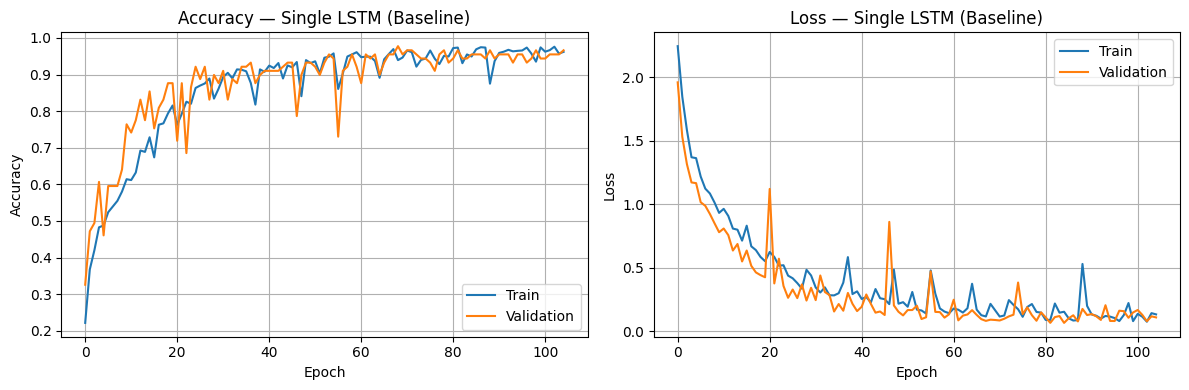

In [5]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy — Single LSTM (Baseline)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss — Single LSTM (Baseline)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/KachornLuckbasedThSL/KachornThSL/baseline_single_lstm_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [6]:
baseline_acc = max(history.history['val_accuracy'])
baseline_loss = min(history.history['val_loss'])
baseline_epoch = len(history.history['val_accuracy'])

print(f"[BASELINE — Single LSTM]")
print(f"  Best val_accuracy : {baseline_acc:.4f}")
print(f"  Best val_loss     : {baseline_loss:.4f}")
print(f"  Stopped at epoch  : {baseline_epoch}")
print()
print(f"[ORIGINAL — Stacked LSTM]")
print(f"  Best val_accuracy : 0.9888")
print(f"  Stopped at epoch  : 93")
print()
diff = 0.9888 - baseline_acc
print(f"  Accuracy gap (Stacked - Single): {diff:+.4f}")

[BASELINE — Single LSTM]
  Best val_accuracy : 0.9775
  Best val_loss     : 0.0667
  Stopped at epoch  : 105

[ORIGINAL — Stacked LSTM]
  Best val_accuracy : 0.9888
  Stopped at epoch  : 93

  Accuracy gap (Stacked - Single): +0.0113


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3641 (\N{THAI CHARACTER SARA UU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  fig.canvas.d

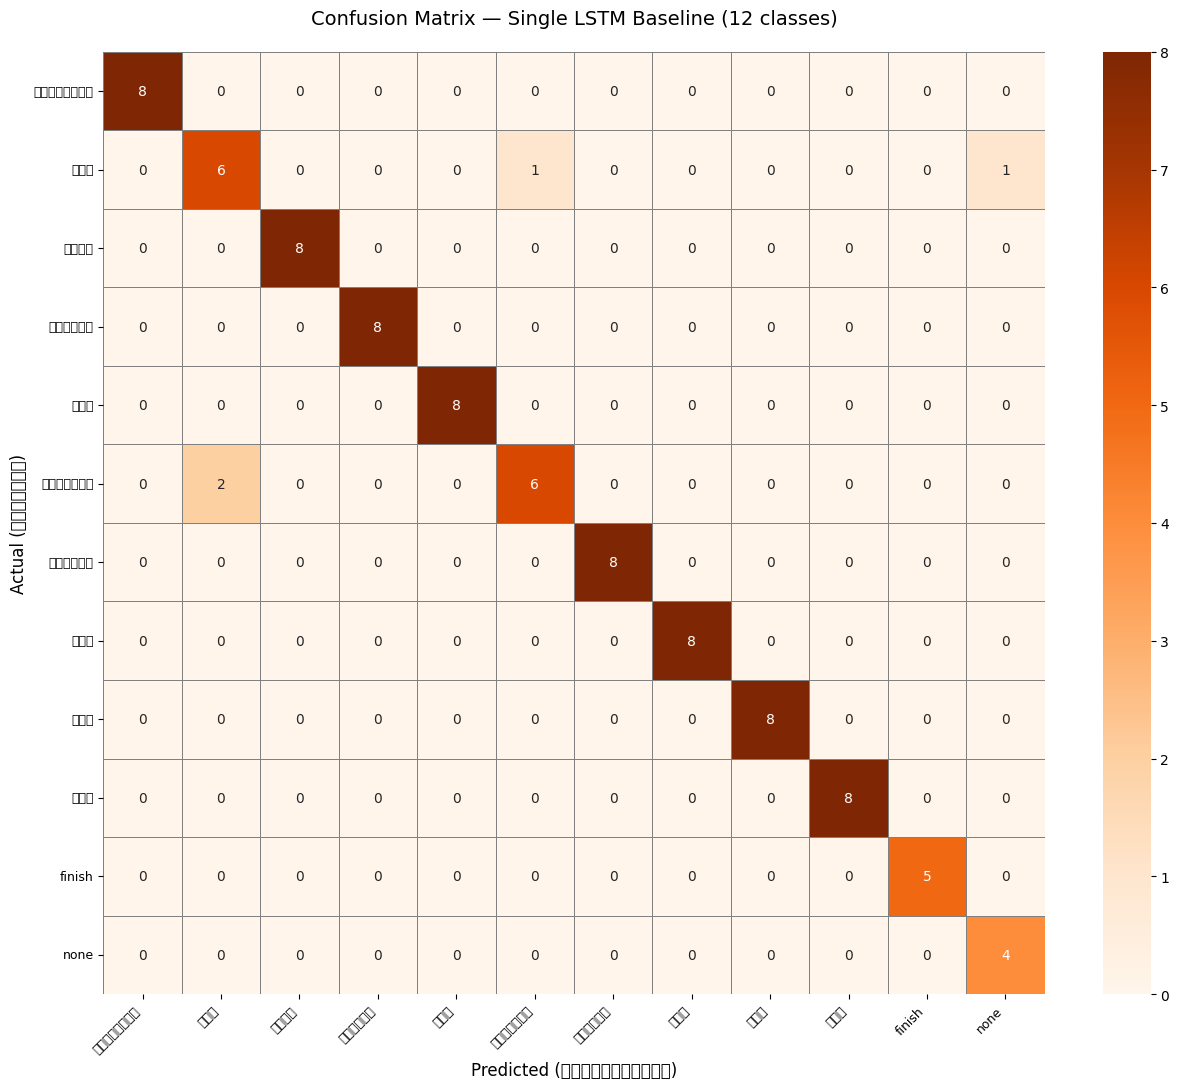

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(13, 11))
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Oranges',
    xticklabels=TARGET_SIGNS,
    yticklabels=TARGET_SIGNS,
    linewidths=0.5, linecolor='gray'
)
plt.title('Confusion Matrix — Single LSTM Baseline (12 classes)', fontsize=14, pad=20)
plt.ylabel('Actual (ท่าจริง)', fontsize=12)
plt.xlabel('Predicted (ท่าที่ทำนาย)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/KachornLuckbasedThSL/KachornThSL/baseline_single_lstm_confusion.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ── Side-by-side comparison table ──
print(f"{'Model':<20} {'Val Accuracy':>14} {'Stopped Epoch':>14}")
print('-' * 50)
print(f"{'Single LSTM':<20} {baseline_acc:>14.4f} {baseline_epoch:>14}")
print(f"{'Stacked LSTM':<20} {'0.9888':>14} {'93':>14}")
print()
print("Same data split (random_state=42), same optimizer, same EarlyStopping.")
print("Only architecture differs — controlled comparison.")

Model                  Val Accuracy  Stopped Epoch
--------------------------------------------------
Single LSTM                  0.9775            105
Stacked LSTM                 0.9888             93

Same data split (random_state=42), same optimizer, same EarlyStopping.
Only architecture differs — controlled comparison.


In [9]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_classes, target_names=TARGET_SIGNS))

              precision    recall  f1-score   support

    คนหูหนวก       1.00      1.00      1.00         8
         คุณ       0.75      0.75      0.75         8
        ช่วย       1.00      1.00      1.00         8
      ขอบคุณ       1.00      1.00      1.00         8
         ฉัน       1.00      1.00      1.00         8
     ต้องการ       0.86      0.75      0.80         8
      เข้าใจ       1.00      1.00      1.00         8
         ไม่       1.00      1.00      1.00         8
         ถาม       1.00      1.00      1.00         8
         บอก       1.00      1.00      1.00         8
      finish       1.00      1.00      1.00         5
        none       0.80      1.00      0.89         4

    accuracy                           0.96        89
   macro avg       0.95      0.96      0.95        89
weighted avg       0.96      0.96      0.95        89

